In [24]:
import time
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import collections
from sklearn.model_selection import train_test_split

In [25]:
df_ratings = pd.read_csv("ml-latest-small/ratings.csv")
train_df, test_df = train_test_split(df_ratings, test_size=0.2, random_state=42)

all_users = sorted(df_ratings["userId"].unique())
all_items = sorted(df_ratings["movieId"].unique())
user_to_idx = {u: i for i, u in enumerate(all_users)}
item_to_idx = {m: j for j, m in enumerate(all_items)}
num_users, num_items = len(all_users), len(all_items)

print(f"Voti totali: {len(df_ratings)} | train: {len(train_df)} | test: {len(test_df)}")
print(f"Utenti: {num_users} | Film: {num_items} | "
      f"Densità: {len(df_ratings)/(num_users*num_items)*100:.2f}%")

Voti totali: 100836 | train: 80668 | test: 20168
Utenti: 610 | Film: 9724 | Densità: 1.70%


In [26]:
# Triple per il train
train_users   = train_df["userId"].map(user_to_idx).to_numpy()
train_items   = train_df["movieId"].map(item_to_idx).to_numpy()
train_ratings = train_df["rating"].to_numpy(dtype=np.float64)

# Triple per il test
test_users   = test_df["userId"].map(user_to_idx).to_numpy()
test_items   = test_df["movieId"].map(item_to_idx).to_numpy()
test_ratings = test_df["rating"].to_numpy(dtype=np.float64)

print(f"Triple train: {len(train_ratings)}")
print(f"Triple test : {len(test_ratings)}")

Triple train: 80668
Triple test : 20168


In [27]:
# Baseline di riferimento: predittore "media globale"
mu = train_ratings.mean()
baseline_rmse = np.sqrt(np.mean((test_ratings - mu) ** 2))
print(f"Baseline (media μ={mu:.3f}): RMSE test = {baseline_rmse:.4f}")

# Funzione ausiliaria per ricalcolare la baseline su un sottoinsieme qualsiasi
def baseline_rmse_on(ratings):
    return np.sqrt(np.mean((ratings - mu) ** 2))

Baseline (media μ=3.503): RMSE test = 1.0488


### Perché non usiamo la SVD classica?

La fattorizzazione $R \approx PQ^T$ ricorda molto la SVD troncata. Perché allora
non applicare direttamente `np.linalg.svd` alla matrice utenti × film?

Il problema è che la SVD è definita solo su matrici **complete**, mentre la nostra
matrice di rating è nota solo all'1.70% delle celle: il restante 98.3% non contiene
zeri, contiene **valori mancanti**. Ed è proprio quel 98.3% ciò che vogliamo predire.

In [28]:
# La matrice utenti × film: le celle non votate sono NaN, non zero.
R = df_ratings.pivot(index="userId", columns="movieId", values="rating").to_numpy(dtype=np.float64)

print(f"Shape: {R.shape} | Memoria: {R.nbytes / 1e6:.1f} MB")
print(f"Celle mancanti (NaN): {np.isnan(R).mean() * 100:.1f}%")

# La SVD di libreria (LAPACK) non ammette NaN: non riesce a convergere.
try:
    U, S, Vt = np.linalg.svd(R, full_matrices=False)
except np.linalg.LinAlgError as e:
    print(f"\n>>> np.linalg.LinAlgError: {e}")

Shape: (610, 9724) | Memoria: 47.5 MB
Celle mancanti (NaN): 98.3%

>>> np.linalg.LinAlgError: SVD did not converge


In [ ]:
# Rattoppo ingenuo: riempiamo i mancanti con 0 così la SVD "gira".
R_zero = np.zeros((num_users, num_items))
R_zero[train_users, train_items] = train_ratings          # solo i voti di train

U, S, Vt = np.linalg.svd(R_zero, full_matrices=False)     
k_svd = 20
R_hat = (U[:, :k_svd] * S[:k_svd]) @ Vt[:k_svd]           # ricostruzione di rango 20

preds_svd = R_hat[test_users, test_items]
rmse_svd  = np.sqrt(np.mean((test_ratings - preds_svd) ** 2))

print(f"SVD zero-filled (k={k_svd}): RMSE test = {rmse_svd:.4f}")
print(f"Voto medio predetto: {preds_svd.mean():.2f}  (i voti reali stanno tra 0.5 e 5.0)")
print(f"Baseline media globale : RMSE = {baseline_rmse:.4f}")

SVD zero-filled (k=20): RMSE test = 3.0233
Voto medio predetto: 0.71  (i voti reali stanno tra 0.5 e 5.0)
Baseline media globale : RMSE = 1.0488


In [30]:
def predict(P, Q, users, items, clip=True):
    """Predizione r_ui ≈ p_u^T q_i su un batch di triple."""
    preds = np.sum(P[users] * Q[items], axis=1)
    if clip:
        np.clip(preds, 0.5, 5.0, out=preds)
    return preds

def rmse(P, Q, users, items, ratings):
    preds = predict(P, Q, users, items)
    return np.sqrt(np.mean((ratings - preds) ** 2))

In [ ]:
def compute_loss(P, Q, users, items, ratings, reg):
    # Il termine di regolarizzazione somma ||p_u||^2 e ||q_i||^2 una volta
    # per osservazione, coerentemente con l'update SGD che applica la penalità
    # a ogni visita. Non è l'energia classica del problema MF (una penalità
    # per fattore), quindi il valore stampato va interpretato di conseguenza.
    err = ratings - predict(P, Q, users, items, clip=False)
    sse = np.sum(err ** 2)
    reg_term = reg * (np.sum(P[users] ** 2) + np.sum(Q[items] ** 2))
    return sse + reg_term

In [32]:
def train_sgd(train_users, train_items, train_ratings,
              test_users, test_items, test_ratings,
              num_users, num_items, k=50,
              lr=0.005, reg=0.02, n_epochs=20,
              init_scale=0.1, seed=42, verbose=True):

    rng = np.random.default_rng(seed)
    P = rng.normal(0.0, init_scale, size=(num_users, k))
    Q = rng.normal(0.0, init_scale, size=(num_items, k))

    n = len(train_ratings)
    history = {"loss": [], "rmse_train": [], "rmse_test": [], "time": []}
    t0 = time.perf_counter()

    for epoch in range(1, n_epochs + 1):
        order = rng.permutation(n)               # shuffle dell'ordine di visita
        for idx in order:
            u = train_users[idx]
            i = train_items[idx]
            r = train_ratings[idx]

            pu = P[u].copy()                     # copia: serve l'aggiornamento simultaneo
            qi = Q[i].copy()
            err = r - pu @ qi                    # residuo e_ui

            P[u] = pu + lr * (err * qi - reg * pu)
            Q[i] = qi + lr * (err * pu - reg * qi)

        # metriche di fine epoca
        history["loss"].append(compute_loss(P, Q, train_users, train_items, train_ratings, reg))
        history["rmse_train"].append(rmse(P, Q, train_users, train_items, train_ratings))
        history["rmse_test"].append(rmse(P, Q, test_users, test_items, test_ratings))
        history["time"].append(time.perf_counter() - t0)

        if verbose:
            print(f"Epoca {epoch:2d} | loss {history['loss'][-1]:11.1f} | "
                  f"RMSE train {history['rmse_train'][-1]:.4f} | "
                  f"RMSE test {history['rmse_test'][-1]:.4f}")

    return P, Q, history

In [33]:
train_item_set = set(train_items.tolist())
seen_mask = np.array([it in train_item_set for it in test_items])
n_cold = int((~seen_mask).sum())

print(f"Voti test su film mai visti in train: {n_cold} / {len(test_items)} "
      f"({100 * n_cold / len(test_items):.1f}%)")


Voti test su film mai visti in train: 813 / 20168 (4.0%)


In [34]:
test_users_w   = test_users[seen_mask]
test_items_w   = test_items[seen_mask]
test_ratings_w = test_ratings[seen_mask]

baseline_rmse_w = baseline_rmse_on(test_ratings_w)
print(f"Baseline su test warm: RMSE = {baseline_rmse_w:.4f}")

Baseline su test warm: RMSE = 1.0450


In [ ]:
# SVD centrata: vengono riempiti i mancanti con la media globale μ (confronto equo).
R_mean = np.full((num_users, num_items), mu)
R_mean[train_users, train_items] = train_ratings

U2, S2, Vt2 = np.linalg.svd(R_mean, full_matrices=False)
R_hat2 = (U2[:, :k_svd] * S2[:k_svd]) @ Vt2[:k_svd]

# Metriche SVD zero-filled su test warm (R_hat calcolato in precedenza)
preds_svd_w   = R_hat[test_users_w, test_items_w]
rmse_svd_w    = np.sqrt(np.mean((test_ratings_w - preds_svd_w) ** 2))

# Metriche SVD mean-filled
preds_svd2    = R_hat2[test_users, test_items]
rmse_svd2     = np.sqrt(np.mean((test_ratings - preds_svd2) ** 2))
preds_svd2_w  = R_hat2[test_users_w, test_items_w]
rmse_svd2_w   = np.sqrt(np.mean((test_ratings_w - preds_svd2_w) ** 2))

print("Confronto su test warm (sottoinsieme omogeneo con SGD/ADAM):")
print(f"  Baseline media globale   : RMSE = {baseline_rmse_w:.4f}")
print(f"  SVD zero-filled (k={k_svd})  : RMSE = {rmse_svd_w:.4f}")
print(f"  SVD mean-filled (k={k_svd})  : RMSE = {rmse_svd2_w:.4f}")
print(f"\nVoto medio predetto (mean-filled): {preds_svd2.mean():.2f}")

Confronto su test warm (sottoinsieme omogeneo con SGD/ADAM):
  Baseline media globale   : RMSE = 1.0450
  SVD zero-filled (k=20)  : RMSE = 3.0048
  SVD mean-filled (k=20)  : RMSE = 0.9938

Voto medio predetto (mean-filled): 3.54


In [36]:
lrs = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
results = {}

for lr in lrs:
    P_, Q_, h_ = train_sgd(
        train_users, train_items, train_ratings,
        test_users_w, test_items_w, test_ratings_w,   # valutazione warm
        num_users, num_items,
        k=20, lr=lr, reg=0.05, n_epochs=20, verbose=False,
    )
    results[lr] = h_
    final = h_["rmse_test"][-1]
    status = "ok" if np.isfinite(final) else "DIVERGE"
    print(f"lr={lr:<6} -> RMSE test(warm) finale: {final:.4f}  [{status}]")

lr=0.001  -> RMSE test(warm) finale: 1.7189  [ok]
lr=0.002  -> RMSE test(warm) finale: 1.1772  [ok]
lr=0.005  -> RMSE test(warm) finale: 0.9487  [ok]
lr=0.01   -> RMSE test(warm) finale: 0.9004  [ok]
lr=0.02   -> RMSE test(warm) finale: 0.8992  [ok]
lr=0.05   -> RMSE test(warm) finale: 0.9274  [ok]


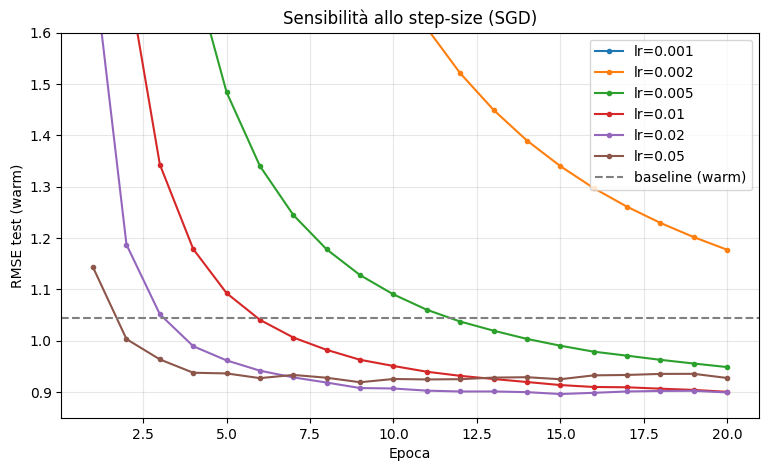

In [37]:
plt.figure(figsize=(9, 5))
for lr, h in results.items():
    curve = np.array(h["rmse_test"])
    if np.all(np.isfinite(curve)):
        plt.plot(range(1, len(curve) + 1), curve, marker="o", ms=3, label=f"lr={lr}")
    else:
        plt.plot([], [], label=f"lr={lr} (diverge)")

plt.axhline(baseline_rmse_w, ls="--", color="gray", label="baseline (warm)")
plt.ylim(0.85, 1.6)
plt.xlabel("Epoca"); plt.ylabel("RMSE test (warm)")
plt.title("Sensibilità allo step-size (SGD)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [38]:
def train_adam(train_users, train_items, train_ratings,
               test_users, test_items, test_ratings,
               num_users, num_items, k=20,
               lr=0.01, reg=0.05, n_epochs=20,
               beta1=0.9, beta2=0.999, eps=1e-8,
               init_scale=0.1, seed=42, verbose=True):

    rng = np.random.default_rng(seed)
    P = rng.normal(0.0, init_scale, size=(num_users, k))
    Q = rng.normal(0.0, init_scale, size=(num_items, k))

    # momenti 1° e 2° per ogni parametro (stessa shape di P, Q)
    mP = np.zeros_like(P); vP = np.zeros_like(P)
    mQ = np.zeros_like(Q); vQ = np.zeros_like(Q)
    # contatori di aggiornamento per-parametro (bias-correction sparsa)
    tP = np.zeros(num_users, dtype=np.int64)
    tQ = np.zeros(num_items, dtype=np.int64)

    n = len(train_ratings)
    history = {"loss": [], "rmse_train": [], "rmse_test": [], "time": []}
    t0 = time.perf_counter()

    for epoch in range(1, n_epochs + 1):
        order = rng.permutation(n)
        for idx in order:
            u = train_users[idx]; i = train_items[idx]; r = train_ratings[idx]

            pu = P[u].copy(); qi = Q[i].copy()
            err = r - pu @ qi

            g_p = -err * qi + reg * pu        # gradienti (valori 'vecchi')
            g_q = -err * pu + reg * qi

            # --- ADAM su p_u ---
            tP[u] += 1
            mP[u] = beta1 * mP[u] + (1 - beta1) * g_p
            vP[u] = beta2 * vP[u] + (1 - beta2) * (g_p * g_p)
            m_hat = mP[u] / (1 - beta1 ** tP[u])
            v_hat = vP[u] / (1 - beta2 ** tP[u])
            P[u] = pu - lr * m_hat / (np.sqrt(v_hat) + eps)

            # --- ADAM su q_i ---
            tQ[i] += 1
            mQ[i] = beta1 * mQ[i] + (1 - beta1) * g_q
            vQ[i] = beta2 * vQ[i] + (1 - beta2) * (g_q * g_q)
            m_hat = mQ[i] / (1 - beta1 ** tQ[i])
            v_hat = vQ[i] / (1 - beta2 ** tQ[i])
            Q[i] = qi - lr * m_hat / (np.sqrt(v_hat) + eps)

        history["loss"].append(compute_loss(P, Q, train_users, train_items, train_ratings, reg))
        history["rmse_train"].append(rmse(P, Q, train_users, train_items, train_ratings))
        history["rmse_test"].append(rmse(P, Q, test_users, test_items, test_ratings))
        history["time"].append(time.perf_counter() - t0)

        if verbose:
            print(f"Epoca {epoch:2d} | loss {history['loss'][-1]:11.1f} | "
                  f"RMSE train {history['rmse_train'][-1]:.4f} | "
                  f"RMSE test {history['rmse_test'][-1]:.4f}")

    return P, Q, history

In [39]:
lrs = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
results_adam = {}

for lr in lrs:
    P_, Q_, h_ = train_adam(
        train_users, train_items, train_ratings,
        test_users_w, test_items_w, test_ratings_w,
        num_users, num_items,
        k=20, lr=lr, reg=0.05, n_epochs=20, verbose=False,
    )
    results_adam[lr] = h_
    print(f"lr={lr:<6} -> ADAM RMSE finale: {h_['rmse_test'][-1]:.4f}")

lr=0.001  -> ADAM RMSE finale: 1.4901
lr=0.002  -> ADAM RMSE finale: 1.2007
lr=0.005  -> ADAM RMSE finale: 1.0040
lr=0.01   -> ADAM RMSE finale: 0.9380
lr=0.02   -> ADAM RMSE finale: 0.9305
lr=0.05   -> ADAM RMSE finale: 0.9602


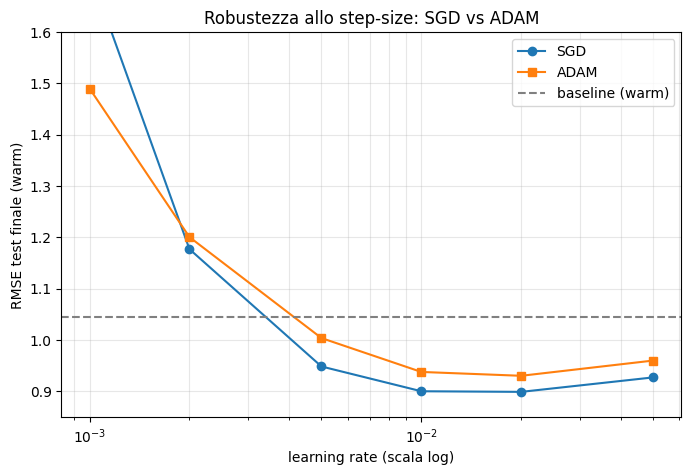

In [ ]:
def final_rmse(h):
    v = h["rmse_test"][-1]
    return v if np.isfinite(v) else np.nan

sgd_finals  = [final_rmse(results[lr])      for lr in lrs]
adam_finals = [final_rmse(results_adam[lr]) for lr in lrs]

plt.figure(figsize=(8, 5))
plt.plot(lrs, sgd_finals,  "o-", label="SGD")
plt.plot(lrs, adam_finals, "s-", label="ADAM")
plt.axhline(baseline_rmse_w, ls="--", color="gray", label="baseline (warm)")
plt.xscale("log")
plt.ylim(0.85, 1.6)
plt.xlabel("learning rate (scala log)"); plt.ylabel("RMSE test finale (warm)")
plt.title("Robustezza allo step-size: SGD vs ADAM")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.show()

In [41]:
for lr in [0.01, 0.02]:
    print(f"lr={lr}: SGD {results[lr]['time'][-1]:5.1f}s | "
          f"ADAM {results_adam[lr]['time'][-1]:5.1f}s")

lr=0.01: SGD   8.4s | ADAM  60.6s
lr=0.02: SGD   8.4s | ADAM  54.7s


In [42]:
def epochs_to_target(h, target):
    for e, r in enumerate(h["rmse_test"], 1):
        if r <= target:
            return e
    return None

tgt = 0.95
for name, store in [("SGD", results), ("ADAM", results_adam)]:
    e = epochs_to_target(store[0.02], tgt)
    print(f"{name} (lr=0.02): epoche per RMSE<{tgt}: {e}")

SGD (lr=0.02): epoche per RMSE<0.95: 6
ADAM (lr=0.02): epoche per RMSE<0.95: 11


## Il modello all'opera: raccomandazioni e film simili

Chiuso il confronto numerico, mostriamo il *payoff* applicativo del modello. I
fattori latenti appresi $P$ e $Q$ non servono solo a stimare un RMSE: codificano
gusti degli utenti e caratteristiche dei film in uno spazio a bassa dimensione.
Li usiamo per due compiti concreti e verificabili a occhio:

1. **Raccomandazione** — per un utente $u$ ordiniamo i film non ancora visti in
   base al punteggio $\hat r_{ui} = q_i^\top p_u$, e confrontiamo i suggerimenti
   con i film che ha effettivamente amato di più.
2. **Similarità tra film** — misuriamo la vicinanza (coseno) tra i vettori $q_i$
   nello spazio latente: film con $q_i$ vicini tendono a piacere allo stesso
   tipo di pubblico.

*(Nota: i punteggi mostrati sono i prodotti scalari $q_i^\top p_u$ non ricalibrati
sulla scala [0.5, 5.0]; vanno letti come punteggi di ordinamento, non come voti
predetti esatti.)*


In [43]:
P_final, Q_final, hist_final = train_sgd(
    train_users, train_items, train_ratings,
    test_users_w, test_items_w, test_ratings_w,
    num_users, num_items,
    k=20, lr=0.02, reg=0.05, n_epochs=20, verbose=False,
)
print(f"Modello finale - RMSE test(warm): {hist_final['rmse_test'][-1]:.4f}")

Modello finale - RMSE test(warm): 0.8992


In [44]:
movies = pd.read_csv("ml-latest-small/movies.csv")
id_to_title  = dict(zip(movies.movieId, movies.title))
id_to_genres = dict(zip(movies.movieId, movies.genres))
idx_to_item  = {j: m for m, j in item_to_idx.items()}
item_counts  = collections.Counter(train_items.tolist())

def film_piu_votati(user_id, n=5):
    sub = train_df[train_df.userId == user_id].sort_values("rating", ascending=False)
    return [(id_to_title.get(m, m), r) for m, r in zip(sub.movieId, sub.rating)][:n]

def raccomanda(user_id, N=10, diagnostica=False):
    u = user_to_idx[user_id]
    scores = Q_final @ P_final[u]
    visti = set(train_df.loc[train_df.userId == user_id, "movieId"])
    if diagnostica:
        print(f"{'score':>6} {'n_voti':>7}  titolo")
    recs = []
    for j in np.argsort(-scores):
        if j not in train_item_set:
            continue
        mid = idx_to_item[j]
        if mid in visti:
            continue
        if diagnostica:
            print(f"{scores[j]:>6.2f} {item_counts[j]:>7}  {id_to_title.get(mid)}")
        recs.append((id_to_title.get(mid, mid), scores[j]))
        if len(recs) == N:
            break
    return recs

uid = 414
print(f"=== Utente {uid}: i film che ha amato di più ===")
for titolo, voto in film_piu_votati(uid):
    print(f"  {voto:.1f}  {titolo}")

print(f"\n=== Top-10 raccomandazioni del modello ===")
for titolo, score in raccomanda(uid):
    print(f"  {score:.2f}  {titolo}")

=== Utente 414: i film che ha amato di più ===
  5.0  American Beauty (1999)
  5.0  American Graffiti (1973)
  5.0  Princess and the Warrior, The (Krieger und die Kaiserin, Der) (2000)
  5.0  Princess Bride, The (1987)
  5.0  Slap Shot (1977)

=== Top-10 raccomandazioni del modello ===
  4.80  Three Billboards Outside Ebbing, Missouri (2017)
  4.76  Big Sleep, The (1946)
  4.75  Little Big Man (1970)
  4.75  Philadelphia Story, The (1940)
  4.75  Hustler, The (1961)
  4.72  Celebration, The (Festen) (1998)
  4.69  Gallipoli (1981)
  4.68  Trial, The (Procès, Le) (1962)
  4.68  Guess Who's Coming to Dinner (1967)
  4.64  Lifeboat (1944)


In [45]:
_ = raccomanda(414, diagnostica=True)

 score  n_voti  titolo
  4.80       5  Three Billboards Outside Ebbing, Missouri (2017)
  4.76      11  Big Sleep, The (1946)
  4.75      16  Little Big Man (1970)
  4.75      24  Philadelphia Story, The (1940)
  4.75      13  Hustler, The (1961)
  4.72       7  Celebration, The (Festen) (1998)
  4.69       7  Gallipoli (1981)
  4.68       4  Trial, The (Procès, Le) (1962)
  4.68       9  Guess Who's Coming to Dinner (1967)
  4.64       6  Lifeboat (1944)


In [ ]:
def film_simili_pop(movie_id, N=10, min_voti=50):
    j  = item_to_idx[movie_id]
    Qn = Q_final / (np.linalg.norm(Q_final, axis=1, keepdims=True) + 1e-9)
    sim = Qn @ Qn[j]
    out = []
    for k in np.argsort(-sim):
        if k == j or item_counts.get(k, 0) < min_voti:     # salta sé stesso e i film poco votati
            continue
        mid = idx_to_item[k]
        out.append((id_to_title.get(mid), id_to_genres.get(mid), sim[k]))
        if len(out) == N:
            break
    return out

mid = 1
print(f"Film simili a: {id_to_title.get(mid)}  [{id_to_genres.get(mid)}]")
for titolo, generi, s in film_simili_pop(mid):
    print(f"  {s:.2f}  {titolo}  [{generi}]")

Film simili a: Toy Story (1995)  [Adventure|Animation|Children|Comedy|Fantasy]
  0.93  Finding Nemo (2003)  [Adventure|Animation|Children|Comedy]
  0.92  Monsters, Inc. (2001)  [Adventure|Animation|Children|Comedy|Fantasy]
  0.91  Mrs. Doubtfire (1993)  [Comedy|Drama]
  0.90  Bug's Life, A (1998)  [Adventure|Animation|Children|Comedy]
  0.90  Die Hard 2 (1990)  [Action|Adventure|Thriller]
  0.90  Incredibles, The (2004)  [Action|Adventure|Animation|Children|Comedy]
  0.90  Big (1988)  [Comedy|Drama|Fantasy|Romance]
  0.89  Princess Bride, The (1987)  [Action|Adventure|Comedy|Fantasy|Romance]
  0.89  Aladdin (1992)  [Adventure|Animation|Children|Comedy|Musical]
  0.89  Shawshank Redemption, The (1994)  [Crime|Drama]
